# Horrorant Discord — Community Engagement Analysis

Exploratory analysis of ~42k messages from two channels of a long-running Discord server.
The goal is to understand **when** the community is active, **who** drives conversation,
**how fast** people respond, and **how** rarely-active members get drawn in.

| Channel | Role | Character |
|---|---|---|
| `general-empire` | role-gated | active core friend group (~40k msgs) |
| `wnh` | public | largely inactive (~2k msgs) |

The two channels are treated as **two separate stories**, not an apples-to-apples comparison —
one is a small active friend group, the other a historically-active channel that went quiet.

## 1. Load & parse

Each message is flattened into a row: id, timestamp, author, content, and `reply_to`
(only present when someone used Discord's reply button — which is rare here, ~7-8%).
Timestamps are parsed as ISO-8601 and stay in **WIB (UTC+7)**, so all time-of-day analysis
is already in the group's local time.

In [9]:
import json
import pandas as pd

# Load both files
with open("exports/Horrorant - Text Channels - general-empire [1131294696954671275].json", 'r', encoding='utf-8') as f:
    empire_raw = json.load(f)

with open("exports/Horrorant - Text Channels - wnh [1258807133089300513].json", 'r', encoding='utf-8') as f:
    wnh_raw = json.load(f)

# Parse into dataframes
def parse_messages(raw):
    messages = raw['messages']
    df = pd.DataFrame([{
        'message_id': m['id'],
        'timestamp': m['timestamp'],
        'author': m['author']['name'],
        'content': m['content'],
        'reply_to': m.get('reference', {}).get('messageId') if m.get('reference') else None,
        'reactions': m.get('reactions', [])
    } for m in messages])
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
    return df

empire_df = parse_messages(empire_raw)
wnh_df = parse_messages(wnh_raw)

# Quick inspection
for name, df in [('general-empire', empire_df), ('wnh', wnh_df)]:
    print(f"\n--- {name} ---")
    print(f"Total messages: {len(df)}")
    print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print(f"Unique authors: {df['author'].nunique()}")
    print(f"Messages with replies: {df['reply_to'].notna().sum()}")


--- general-empire ---
Total messages: 39799
Date range: 2023-07-20 01:55:46.991000+07:00 to 2026-06-29 22:43:06.846000+07:00
Unique authors: 16
Messages with replies: 2800

--- wnh ---
Total messages: 2156
Date range: 2024-07-05 22:31:04.145000+07:00 to 2026-06-09 23:20:57.489000+07:00
Unique authors: 14
Messages with replies: 184


## 2. Activity patterns — when is the server alive?

Two views: **messages per month** (long-term trend) and an **hour-by-day heatmap**
(daily/weekly rhythm). Watch for the seasonal pattern — volume tracks the university
calendar, spiking during semester breaks (Dec-Jan, Jun-Jul) and dropping during term time.

C:\Users\ficos\AppData\Local\Temp\ipykernel_5856\4189607893.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  empire_df['month'] = empire_df['timestamp'].dt.to_period('M')
C:\Users\ficos\AppData\Local\Temp\ipykernel_5856\4189607893.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  wnh_df['month'] = wnh_df['timestamp'].dt.to_period('M')


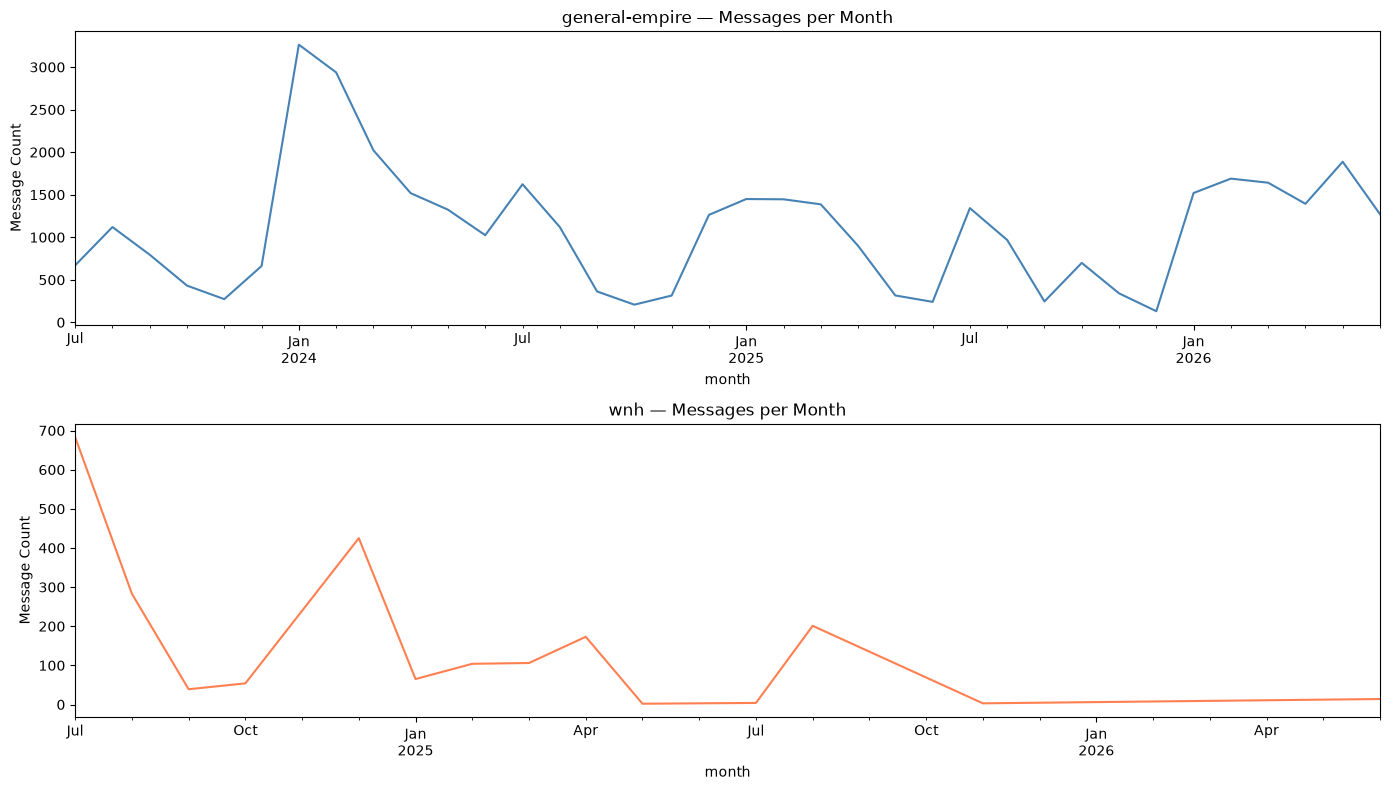

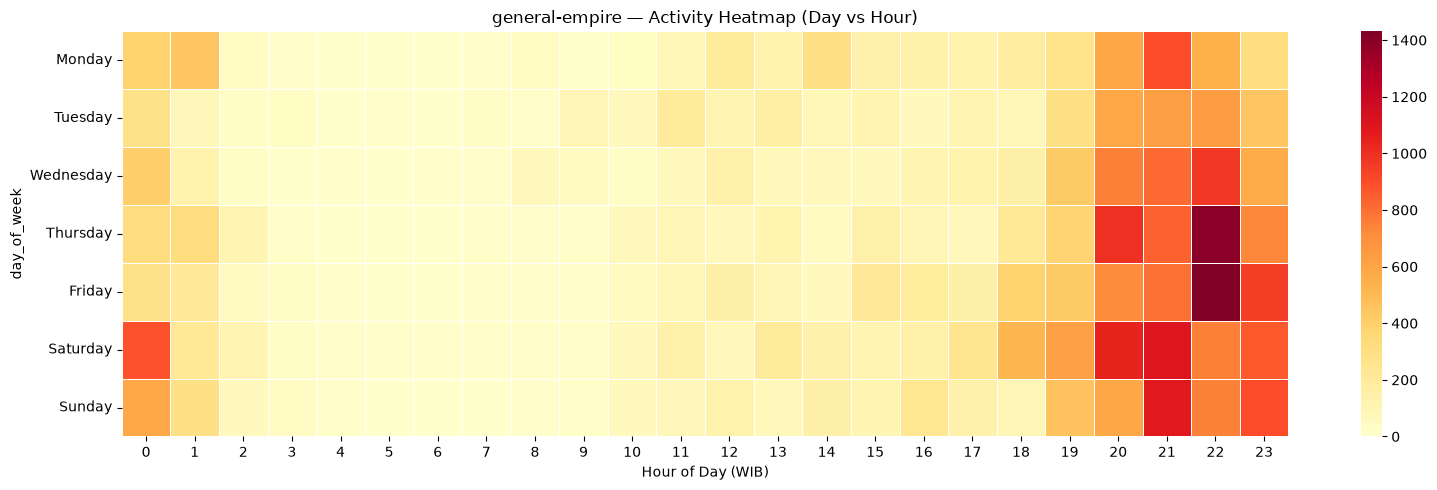

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to local time and extract time components
empire_df['date'] = empire_df['timestamp'].dt.date
empire_df['hour'] = empire_df['timestamp'].dt.hour
empire_df['day_of_week'] = empire_df['timestamp'].dt.day_name()
empire_df['month'] = empire_df['timestamp'].dt.to_period('M')

wnh_df['date'] = wnh_df['timestamp'].dt.date
wnh_df['hour'] = wnh_df['timestamp'].dt.hour
wnh_df['day_of_week'] = wnh_df['timestamp'].dt.day_name()
wnh_df['month'] = wnh_df['timestamp'].dt.to_period('M')

# 1. Messages per month over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

empire_monthly = empire_df.groupby('month').size()
wnh_monthly = wnh_df.groupby('month').size()

empire_monthly.plot(ax=axes[0], title='general-empire — Messages per Month', color='steelblue')
axes[0].set_ylabel('Message Count')

wnh_monthly.plot(ax=axes[1], title='wnh — Messages per Month', color='coral')
axes[1].set_ylabel('Message Count')

plt.tight_layout()
plt.savefig('monthly_volume.png', dpi=150)
plt.show()

# 2. Activity heatmap — hour vs day of week (empire only, wnh too sparse)
pivot = empire_df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5)
plt.title('general-empire — Activity Heatmap (Day vs Hour)')
plt.xlabel('Hour of Day (WIB)')
plt.tight_layout()
plt.savefig('activity_heatmap.png', dpi=150)
plt.show()

## 3. Response time — how fast do people reply?

"Engagement" is operationalized two ways, because explicit replies are too sparse to rely on alone:

- **Proximity (primary):** author B posting within 60 min after author A = B engaging with A.
- **Explicit (validation):** uses the actual `reply_to` field as ground truth.

If both methods give a similar distribution, the proximity assumption is **validated** — this is
the core methodological check of the project. Expect a heavily **right-skewed** distribution:
the median reply is near-instant, with a thin tail of slow stragglers, so the **mean is
misleading and median is the correct statistic.**

=== general-empire ===
Proximity-based responses: 20238
  Median: 15s (0.3 min)
  Mean:   242s (4.0 min)

Explicit-reply responses: 2163
  Median: 50s (0.8 min)
  Mean:   416s (6.9 min)


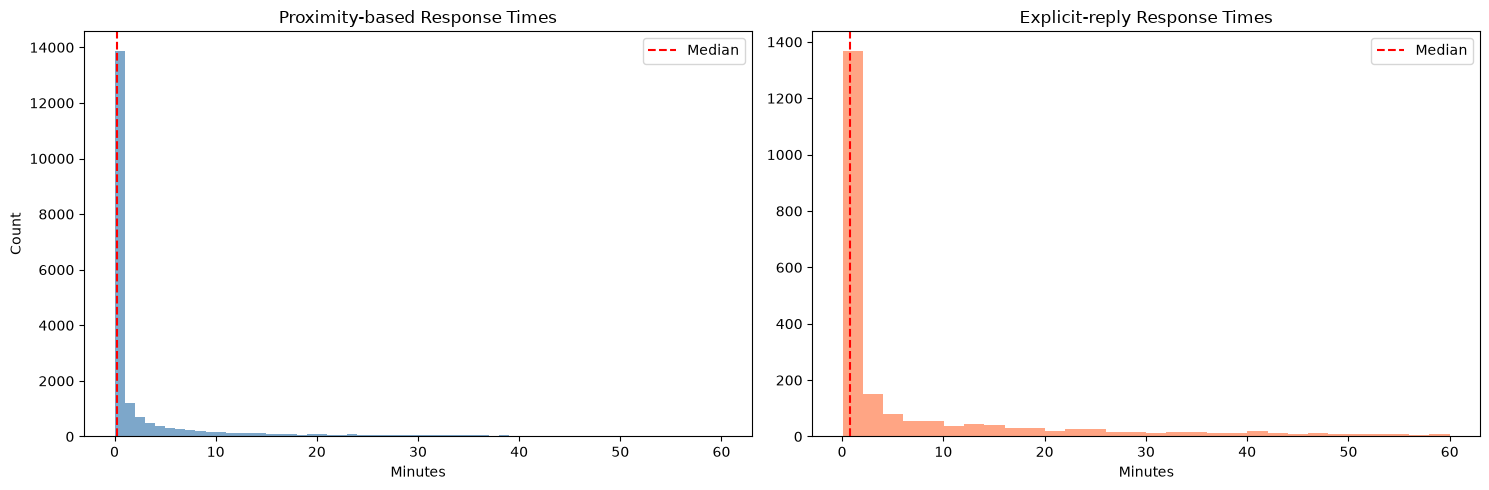

In [11]:
import numpy as np

def compute_response_times(df, gap_threshold_minutes=60):
    """
    Option A: consecutive messages by different authors within threshold.
    Returns response times in seconds.
    """
    df_sorted = df.sort_values('timestamp').reset_index(drop=True)
    
    proximity_responses = []
    for i in range(1, len(df_sorted)):
        prev = df_sorted.iloc[i-1]
        curr = df_sorted.iloc[i]
        
        # different author = potential response
        if curr['author'] != prev['author']:
            gap = (curr['timestamp'] - prev['timestamp']).total_seconds()
            if 0 < gap <= gap_threshold_minutes * 60:
                proximity_responses.append({
                    'responder': curr['author'],
                    'responding_to': prev['author'],
                    'response_seconds': gap
                })
    
    return pd.DataFrame(proximity_responses)

def compute_explicit_response_times(df, gap_threshold_minutes=60):
    """
    Option B: explicit reply_to chains.
    """
    id_to_time = dict(zip(df['message_id'], df['timestamp']))
    id_to_author = dict(zip(df['message_id'], df['author']))
    
    explicit_responses = []
    for _, row in df[df['reply_to'].notna()].iterrows():
        parent_id = row['reply_to']
        if parent_id in id_to_time:
            gap = (row['timestamp'] - id_to_time[parent_id]).total_seconds()
            if 0 < gap <= gap_threshold_minutes * 60:
                explicit_responses.append({
                    'responder': row['author'],
                    'responding_to': id_to_author[parent_id],
                    'response_seconds': gap
                })
    
    return pd.DataFrame(explicit_responses)

# Compute for general-empire
empire_proximity = compute_response_times(empire_df)
empire_explicit = compute_explicit_response_times(empire_df)

print("=== general-empire ===")
print(f"Proximity-based responses: {len(empire_proximity)}")
print(f"  Median: {empire_proximity['response_seconds'].median():.0f}s ({empire_proximity['response_seconds'].median()/60:.1f} min)")
print(f"  Mean:   {empire_proximity['response_seconds'].mean():.0f}s ({empire_proximity['response_seconds'].mean()/60:.1f} min)")
print(f"\nExplicit-reply responses: {len(empire_explicit)}")
print(f"  Median: {empire_explicit['response_seconds'].median():.0f}s ({empire_explicit['response_seconds'].median()/60:.1f} min)")
print(f"  Mean:   {empire_explicit['response_seconds'].mean():.0f}s ({empire_explicit['response_seconds'].mean()/60:.1f} min)")

# Plot both distributions to check the bimodal pattern + compare methods
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(empire_proximity['response_seconds']/60, bins=60, color='steelblue', alpha=0.7)
axes[0].set_title('Proximity-based Response Times')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')
axes[0].axvline(empire_proximity['response_seconds'].median()/60, color='red', linestyle='--', label='Median')
axes[0].legend()

axes[1].hist(empire_explicit['response_seconds']/60, bins=30, color='coral', alpha=0.7)
axes[1].set_title('Explicit-reply Response Times')
axes[1].set_xlabel('Minutes')
axes[1].axvline(empire_explicit['response_seconds'].median()/60, color='red', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.savefig('response_times.png', dpi=150)
plt.show()

## 4. wnh response time + cross-channel comparison

Same two methods applied to the quiet channel, then overlaid against `general-empire`.
The key insight to look for: if `wnh` responds **just as fast** when it does flicker to life,
then its "death" is a problem of conversation **frequency**, not **quality** — the few
exchanges that happen are as lively as the active channel.

_Caveat: `wnh` has far fewer qualifying responses, so its medians are noisier — treat as suggestive._

=== wnh ===
Proximity-based responses: 958
  Median: 15s (0.2 min)
  Mean:   206s (3.4 min)

Explicit-reply responses: 140
  Median: 61s (1.0 min)
  Mean:   507s (8.4 min)


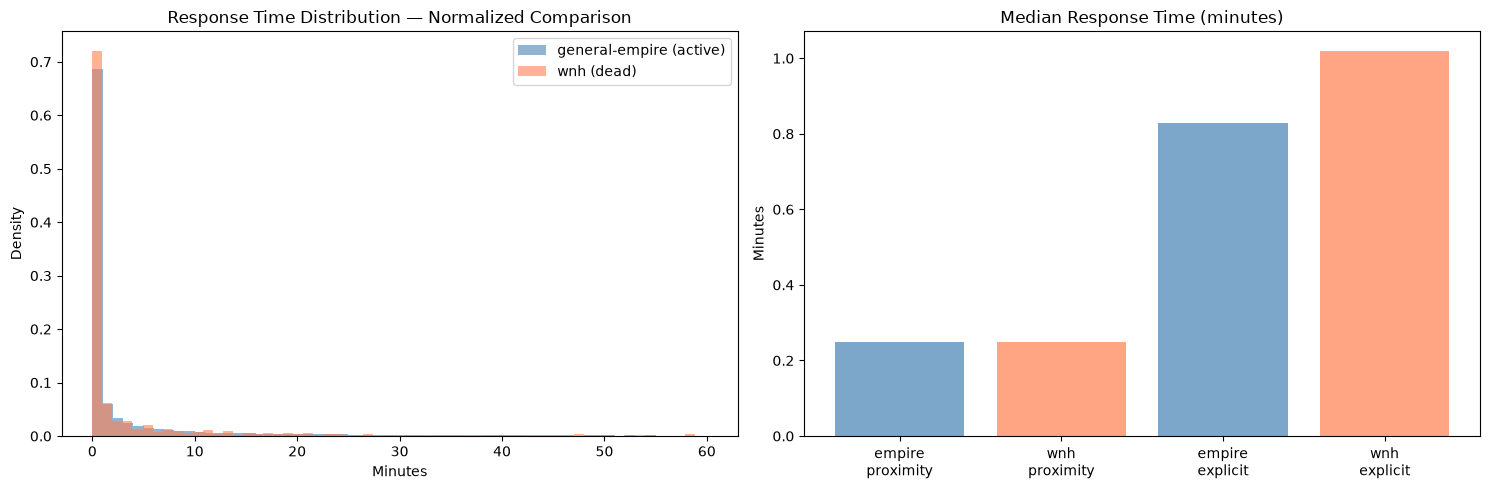

In [12]:
# Compute for wnh
wnh_proximity = compute_response_times(wnh_df)
wnh_explicit = compute_explicit_response_times(wnh_df)

print("=== wnh ===")
print(f"Proximity-based responses: {len(wnh_proximity)}")
print(f"  Median: {wnh_proximity['response_seconds'].median():.0f}s ({wnh_proximity['response_seconds'].median()/60:.1f} min)")
print(f"  Mean:   {wnh_proximity['response_seconds'].mean():.0f}s ({wnh_proximity['response_seconds'].mean()/60:.1f} min)")
print(f"\nExplicit-reply responses: {len(wnh_explicit)}")
if len(wnh_explicit) > 0:
    print(f"  Median: {wnh_explicit['response_seconds'].median():.0f}s ({wnh_explicit['response_seconds'].median()/60:.1f} min)")
    print(f"  Mean:   {wnh_explicit['response_seconds'].mean():.0f}s ({wnh_explicit['response_seconds'].mean()/60:.1f} min)")

# Direct comparison: empire vs wnh proximity distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overlaid histograms (normalized so the two channels are comparable despite size difference)
axes[0].hist(empire_proximity['response_seconds']/60, bins=60, color='steelblue',
             alpha=0.6, density=True, label='general-empire (active)')
axes[0].hist(wnh_proximity['response_seconds']/60, bins=60, color='coral',
             alpha=0.6, density=True, label='wnh (dead)')
axes[0].set_title('Response Time Distribution — Normalized Comparison')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Density')
axes[0].legend()

# Median comparison bar
medians = {
    'empire\nproximity': empire_proximity['response_seconds'].median(),
    'wnh\nproximity': wnh_proximity['response_seconds'].median(),
    'empire\nexplicit': empire_explicit['response_seconds'].median(),
    'wnh\nexplicit': wnh_explicit['response_seconds'].median() if len(wnh_explicit) > 0 else 0,
}
axes[1].bar(medians.keys(), [v/60 for v in medians.values()],
            color=['steelblue','coral','steelblue','coral'], alpha=0.7)
axes[1].set_title('Median Response Time (minutes)')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.savefig('wnh_vs_empire_response.png', dpi=150)
plt.show()

## 5. Conversation network — who talks to whom?

Before any network metric, the data is **cleaned**: bots and non-members removed, and two
accounts belonging to the same person merged into one identity (this correction promotes that
user into the active core).

Two metrics are computed:

- **Weighted interaction volume** — total engagement flowing through each person. This replaces
  plain degree centrality, which *saturates* in a small fully-connected group and can't
  distinguish anyone.
- **Reciprocity** — for each pair, is the relationship balanced (~1.0) or lopsided? High
  reciprocity across all pairs is the signature of a mutual friend group rather than a
  follower/influencer structure.

_Caveat: proximity edges capture "posted adjacent to," not strictly "replied to" — a softer
but reasonable proxy in a small channel._

In [13]:
import networkx as nx

# --- Clean & anonymize ---
# The real-handle -> alias map, plus the list of bots/non-members to drop, lives in
# a separate file (anonymize.py) that is git-ignored and NOT published: it is the
# de-anonymization key. On a fresh clone it is absent, so we fall back to no-ops.
# The notebook can't be re-run publicly anyway -- the raw exports are excluded too.
try:
    from anonymize import bots_and_nonmembers, identity_map, display_names
except ImportError:
    bots_and_nonmembers, identity_map, display_names = [], {}, {}

empire_human = empire_df[~empire_df['author'].isin(bots_and_nonmembers)].copy()
empire_human['author'] = empire_human['author'].replace(identity_map)    # merge alt accounts
empire_human['author'] = empire_human['author'].replace(display_names)   # apply public aliases

print("=== Authors after cleanup + identity merge ===")
print(empire_human['author'].value_counts())

def build_response_network(df, gap_threshold_minutes=60):
    """Proximity edges: author B posting within the window after author A
    counts as B engaging with A. Returns {(responder, target): count}."""
    df_sorted = df.sort_values('timestamp').reset_index(drop=True)
    edges = {}
    for i in range(1, len(df_sorted)):
        prev = df_sorted.iloc[i-1]
        curr = df_sorted.iloc[i]
        if curr['author'] != prev['author']:
            gap = (curr['timestamp'] - prev['timestamp']).total_seconds()
            if 0 < gap <= gap_threshold_minutes * 60:
                pair = (curr['author'], prev['author'])  # responder -> responded_to
                edges[pair] = edges.get(pair, 0) + 1
    return edges

empire_edges = build_response_network(empire_human)

# Active members = those with at least 100 messages (drops one-off noise)
msg_counts = empire_human['author'].value_counts()
active_authors = msg_counts[msg_counts >= 100].index.tolist()
print(f"\nActive human authors (100+ msgs): {len(active_authors)}")

# Weighted interaction volume = the real "hub" measure (in + out edge weight).
# Plain degree centrality saturates in a small fully-connected group, so it is
# NOT used here.
weighted_degree = {}
for (responder, target), w in empire_edges.items():
    weighted_degree[responder] = weighted_degree.get(responder, 0) + w
    weighted_degree[target]    = weighted_degree.get(target, 0) + w

print("\n=== Weighted interaction volume (who is the hub) ===")
total = sum(v for a, v in weighted_degree.items() if a in active_authors)
for author, score in sorted(weighted_degree.items(), key=lambda x: -x[1]):
    if author in active_authors:
        print(f"  {author}: {score}  ({100*score/total:.1f}% of all interactions)")

# Reciprocity: is each relationship balanced (~1.0) or lopsided (<1.0)?
print("\n=== Reciprocity (balance of top relationships) ===")
seen = set()
for (a, b), w in sorted(empire_edges.items(), key=lambda x: -x[1]):
    if a in active_authors and b in active_authors and (b, a) not in seen:
        reverse = empire_edges.get((b, a), 0)
        if w + reverse > 200:
            ratio = min(w, reverse) / max(w, reverse)
            print(f"  {a} <-> {b}: {w}/{reverse}  (balance: {ratio:.2f})")
        seen.add((a, b))


=== Authors after cleanup + identity merge ===
author
purofuro             11415
reinharts             7139
snewdrogos            6574
jojo                  5630
yuhuuu                5455
bambas pamungkang     2924
leon kennedy            85
ampy                    58
Name: count, dtype: int64

Active human authors (100+ msgs): 6

=== Weighted interaction volume (who is the hub) ===
  purofuro: 10019  (25.6% of all interactions)
  snewdrogos: 8411  (21.5% of all interactions)
  reinharts: 6966  (17.8% of all interactions)
  jojo: 5363  (13.7% of all interactions)
  yuhuuu: 5199  (13.3% of all interactions)
  bambas pamungkang: 3130  (8.0% of all interactions)

=== Reciprocity (balance of top relationships) ===
  snewdrogos <-> purofuro: 1578/1554  (balance: 0.98)
  purofuro <-> yuhuuu: 1119/1083  (balance: 0.97)
  reinharts <-> purofuro: 1070/1016  (balance: 0.95)
  reinharts <-> snewdrogos: 970/940  (balance: 0.97)
  snewdrogos <-> jojo: 808/721  (balance: 0.89)
  purofuro <-> jojo: 

### 5b. Network visualization

Node size & color = interaction volume; edge thickness = pair strength.
**Layout positions are aesthetic only** — with ~6 fully-connected nodes, spring-layout
placement is arbitrary, so don't read meaning into *who sits where*. The volume (color/size)
and pair strength (edge width) are what carry information.

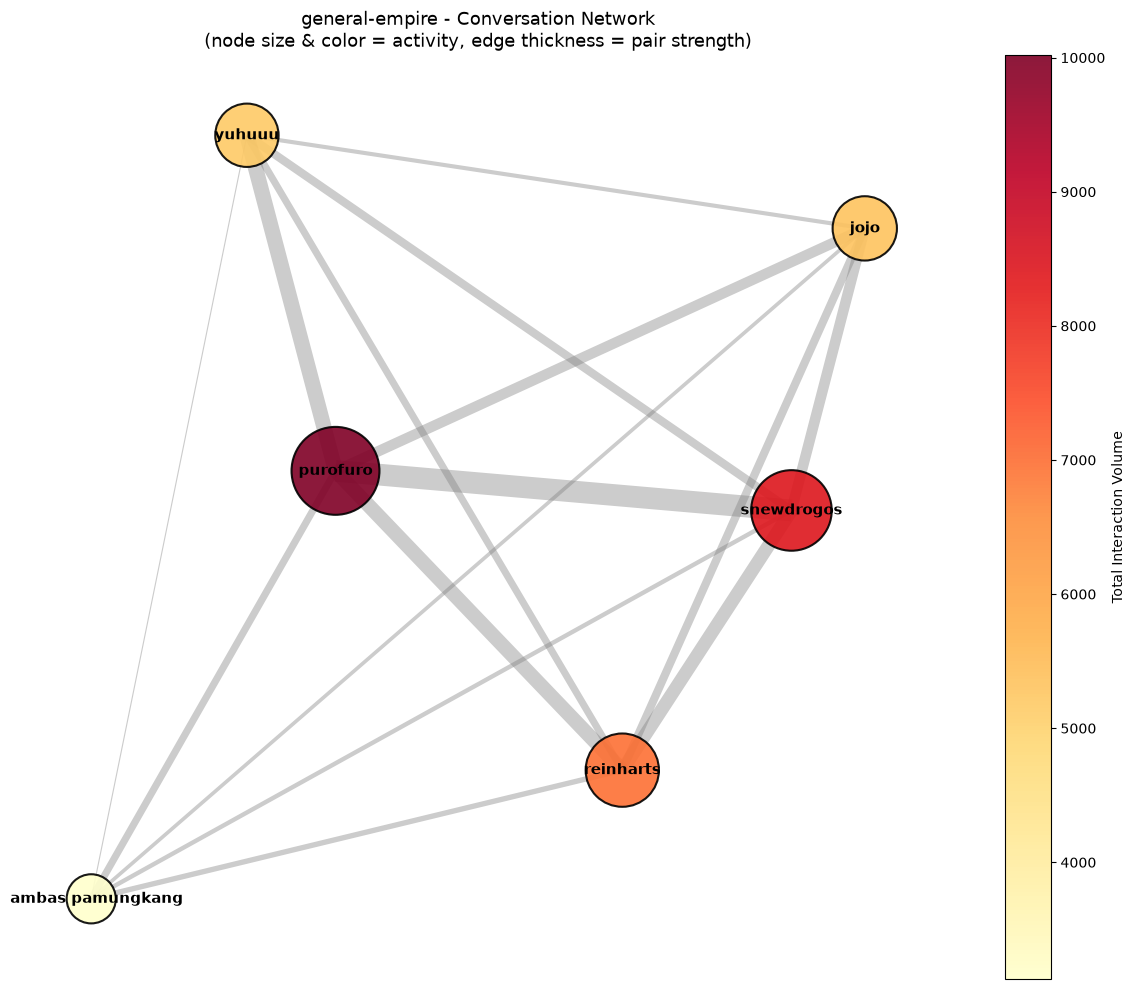

In [14]:
import matplotlib.pyplot as plt

# Collapse directed pairs into undirected weights for edge thickness
undirected_weights = {}
for (a, b), w in empire_edges.items():
    if a in active_authors and b in active_authors:
        key = tuple(sorted([a, b]))
        undirected_weights[key] = undirected_weights.get(key, 0) + w

G_undirected = nx.Graph()
for (a, b), w in undirected_weights.items():
    G_undirected.add_edge(a, b, weight=w)

node_sizes  = [weighted_degree[n] * 0.4 for n in G_undirected.nodes()]
node_colors = [weighted_degree[n] for n in G_undirected.nodes()]
edge_widths = [G_undirected[u][v]['weight'] / 200 for u, v in G_undirected.edges()]

# NOTE: with ~6 fully-connected nodes, layout POSITIONS are arbitrary/aesthetic.
# Only node size+color (volume) and edge thickness (pair strength) carry meaning.
pos = nx.spring_layout(G_undirected, weight='weight', seed=42, k=2)

plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G_undirected, pos, width=edge_widths, alpha=0.4, edge_color='gray')
nodes = nx.draw_networkx_nodes(G_undirected, pos, node_size=node_sizes,
                               node_color=node_colors, cmap='YlOrRd',
                               alpha=0.9, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_undirected, pos, font_size=11, font_weight='bold')
plt.colorbar(nodes, label='Total Interaction Volume')
plt.title('general-empire - Conversation Network\n'
          '(node size & color = activity, edge thickness = pair strength)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('empire_network.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Per-person weekly rhythm

Does each member have their own schedule, or does the group move as one unit?
The **right panel (row-normalized)** is the informative one — it shows each person's activity
as a percent of *their own* total, revealing rhythm independent of volume. The left raw-count
panel mostly just re-encodes who is most active overall.

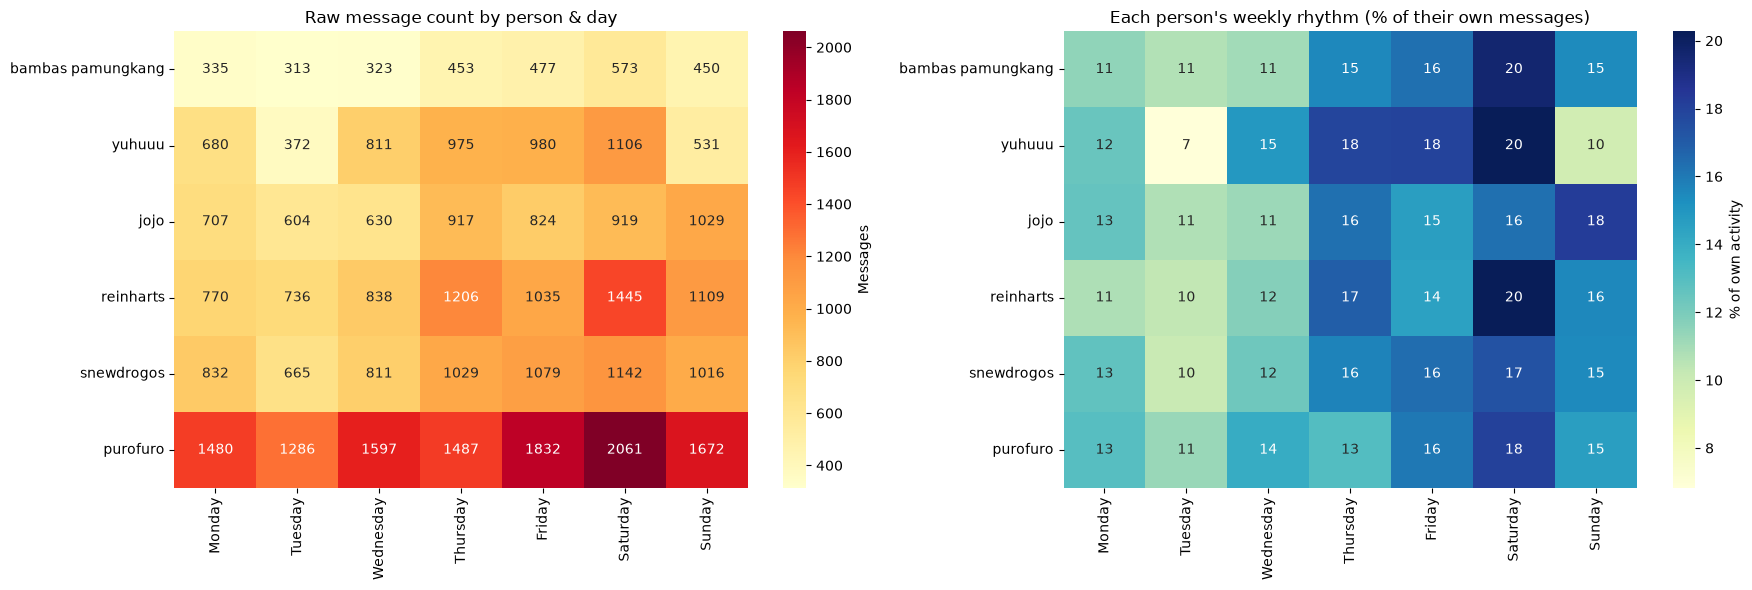

In [15]:
import seaborn as sns

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
author_order = ['bambas pamungkang','yuhuuu','jojo','reinharts','snewdrogos','purofuro']

empire_human['day_of_week'] = empire_human['timestamp'].dt.day_name()

activity = (empire_human[empire_human['author'].isin(author_order)]
            .groupby(['author','day_of_week']).size().unstack(fill_value=0))
activity = activity.reindex(index=author_order, columns=day_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: raw counts (mostly re-encodes total volume)
sns.heatmap(activity, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label':'Messages'})
axes[0].set_title('Raw message count by person & day')
axes[0].set_xlabel(''); axes[0].set_ylabel('')

# Right: row-normalized -> each person's OWN weekly rhythm (the informative panel)
activity_norm = activity.div(activity.sum(axis=1), axis=0) * 100
sns.heatmap(activity_norm, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[1],
            cbar_kws={'label':'% of own activity'})
axes[1].set_title("Each person's weekly rhythm (% of their own messages)")
axes[1].set_xlabel(''); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('per_person_weekly.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Peripheral members — are the quiet ones absorbed or ignored?

The original plan was a "lurker ratio," but that can't be computed from message data: people
who never post don't appear in a message export at all. Reframed into an answerable question:
**when the two rarely-active members do post, who engages with them?**

Comparing engagement *received* vs *given* tests inclusivity. The interesting result to look for
is whether each peripheral member connects through a **specific anchor person** rather than
uniformly through the hub.

_Caveat: these rest on dozens of interactions, not thousands. Trust strong concentrations
(e.g. 27 vs 4); ignore counts of 1-2._

In [16]:
# When the rarely-active members DO post, who engages with them?
# Small-sample analysis: read directions where concentration is strong;
# do not over-read counts of 1-2.
rare_members = ['ampy', 'leon kennedy']

for rare in rare_members:
    n = (empire_human['author'] == rare).sum()
    print(f"\n{'='*50}\n=== {rare} (total messages: {n}) ===")

    responders_to = {a: w for (a, b), w in empire_edges.items() if b == rare}
    responds_to   = {b: w for (a, b), w in empire_edges.items() if a == rare}

    print(f"\n  Who engages right after {rare} (responds TO them):")
    for person, w in sorted(responders_to.items(), key=lambda x: -x[1]):
        print(f"    {person}: {w}")

    print(f"\n  Who {rare} posts right after (responds TO):")
    for person, w in sorted(responds_to.items(), key=lambda x: -x[1]):
        print(f"    {person}: {w}")

    received = sum(responders_to.values())
    given    = sum(responds_to.values())
    print(f"\n  Engagement received: {received} | given: {given}")



=== ampy (total messages: 58) ===

  Who engages right after ampy (responds TO them):
    purofuro: 27
    snewdrogos: 4
    yuhuuu: 2
    bambas pamungkang: 2
    jojo: 1
    reinharts: 1

  Who ampy posts right after (responds TO):
    purofuro: 22
    snewdrogos: 9
    jojo: 3
    yuhuuu: 3
    bambas pamungkang: 2

  Engagement received: 37 | given: 39

=== leon kennedy (total messages: 85) ===

  Who engages right after leon kennedy (responds TO them):
    jojo: 13
    yuhuuu: 13
    purofuro: 5
    reinharts: 4

  Who leon kennedy posts right after (responds TO):
    yuhuuu: 12
    jojo: 10
    reinharts: 6
    purofuro: 3
    snewdrogos: 1
    bambas pamungkang: 1

  Engagement received: 35 | given: 33


## Limitations

- **Proximity != reply.** Edges capture temporal adjacency, a proxy for engagement.
- **No true lurker count.** Silent members don't appear in message exports.
- **Bot/non-member removal is insider-knowledge-based**, not algorithmic, so possibly not exhaustive.
- **Small-sample findings** (peripheral members, wnh medians) are suggestive, not conclusive.
- **The wnh post-Aug-2025 decline** has a cause not captured in the data; described as a pattern only.
- **Network layout positions are decorative**, not meaningful.